Fit parameters:
A = 64031.95325083403
x0 (center wavelength) = 403.37084399824965 nm
sigma = 1.2908134765480417
offset = 485.7686688388343


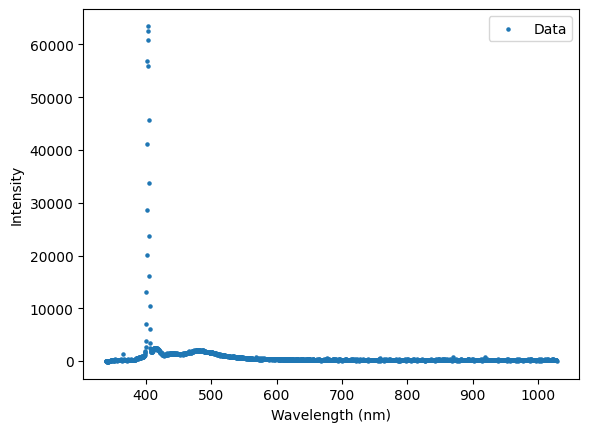

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = np.loadtxt("Data For Curve Fit/28mA_clean.txt")

wavelength = data[:, 0]
intensity = data[:, 1]

#Initial Guess
A_guess = np.max(intensity)
x0_guess = wavelength[np.argmax(intensity)]
sigma_guess = 10
offset_guess = np.min(intensity)

p0 = [A_guess, x0_guess, sigma_guess, offset_guess]

def gaussian(x, A, x0, sigma, offset):
    return A * np.exp(-(x - x0) ** 2 / (2 * sigma**2)) + offset

#Fit 
params, covariance = curve_fit(gaussian, wavelength, intensity, p0=p0)

A, x0, sigma, offset = params

print("Fit parameters:")
print(f"A = {A}")
print(f"x0 (center wavelength) = {x0} nm")
print(f"sigma = {sigma}")
print(f"offset = {offset}")

# Plot 
plt.figure()
plt.scatter(wavelength, intensity, s=5, label="Data")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.legend()
plt.show()